# STOPP


In [4]:
import pickle

with open(r"C:\Users\victo\Downloads\SB_lab\TestFlow\rotations\0_u_v.pkl", 'rb') as f:
    unpickler = pickle.Unpickler(f)  # Remove weights_only if present
    obj = unpickler.load()

In [124]:
import torch
print(torch.__version__)

2.6.0+cu126


In [1]:
from cellpose.io import imread
import cv2
import glob
import matplotlib.pyplot as plt
import numpy as np
from natsort import natsorted
from scipy.ndimage import gaussian_filter
from scipy import spatial
from sklearn.neighbors import KDTree
from scipy.stats import circmean
import os
import sys, time,random
from pathlib import Path
from PIL import Image
from joblib import Parallel, delayed
import h5py
from skimage.measure import label, regionprops


sys.path.append('../defect_functions') 
from defect_pairs import * 
from average_flows import * 


In [2]:
# path = r"E:\HT1080\c3_6well_5min_10x\_4\Pos10"  
# path = r"E:\C2C12 and RPE in 6 well\15min5x\_1\Pos2"
# path = r"C:\Users\victo\OneDrive - BGU\DATA\Hacat\6 Wells _5x_15min\_1\Pos0"
# path = r"C:\Users\victo\Downloads\SB_lab\BEER_DATA\60X_singles"
# path = r"E:\C2C12 and RPE in 6 well\15min5x\_1\Pos20"
path = r"C:\Users\victo\OneDrive - BGU\DATA\Hacat\6Wells_5X_15min_CK666\_1\Pos30"

image_list = natsorted(glob.glob(path + r"\*.tif"), key=lambda y: y.lower())
# img = cv2.imread(image_list[0])[:,:,0]
# analyze_defects(img, sigma=21)


 ## Test Flow and Nematics

In [51]:
%matplotlib qt
# im_num = 120
# flow_sigma = 15
# ori_sigma = 21
# fig,(ax1, ax2) = plt.subplots(1,2,  figsize=(16,8))

def plot_flow_and_nematics(image_list, im_num, axs=None, flow_sigma=15, ori_sigma=21):
    width = -1
    img1 = cv2.imread(image_list[im_num])[:, :width,0]
    img2 = cv2.imread(image_list[im_num+1])[:, :width,0]
    flow = cv2.calcOpticalFlowFarneback(img1,img2, None, 0.5, 3, 
        winsize=flow_sigma, iterations=3, poly_n=5, poly_sigma=1.2, flags=0) 
    flow[..., 0] = flow[..., 0]- np.mean(flow[..., 0])
    flow[..., 1] = flow[..., 1]- np.mean(flow[..., 1])

    step = int(flow_sigma*1.)

    if axs is None:
        fig, axs = plt.subplots(1,2,  figsize=(16,8))
    
    axs[0].axis('off'); axs[1].axis('off')   
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    img_clahe = clahe.apply(img1)
    axs[0].imshow(255-img_clahe, cmap="gray")  
    axs[0].set_title(image_list[im_num])
    

    y, x = np.mgrid[0:img1.shape[0], 0:img1.shape[1]]
    axs[0].quiver(x[::step, ::step], y[::step, ::step], 
            flow[::step, ::step, 0], -flow[::step, ::step, 1], 
            color="red", scale=80, alpha=.5, width=.005)


    ori, plus, min = analyze_defects(img1, sigma=ori_sigma)

    s = int(flow_sigma*1)
    # axs[1].imshow(np.zeros_like(img1, dtype=np.float32), cmap="gray")
    axs[1].imshow(255-img_clahe, cmap="gray")


    quiver = axs[1].quiver(x[::s,::s], y[::s,::s],
        np.cos(ori)[::s,::s], np.sin(ori)[::s,::s], np.arctan2(np.sin(ori), np.cos(ori))[::s,::s],
        headaxislength=0, headwidth=0, headlength=0, width=.005, 
        scale=60, pivot='mid', alpha=.5, cmap="hsv")

    alpha_half, scale_half = .8, 15    
    axs[1].plot(plus['x'], plus['y'],'ro',markersize=8, alpha=alpha_half)
    axs[1].quiver(plus['x'], plus['y'], 
        np.cos(plus['ang1']), -np.sin(plus['ang1']), 
        headaxislength=0, headwidth=0, headlength=0, color='r', scale=scale_half, alpha=alpha_half)

    axs[1].plot(min['x'], min['y'],'o',markersize=6, alpha=alpha_half, color='dodgerblue')
    for j in range(3):
        axs[1].quiver(min['x'], min['y'], 
            np.cos(min['ang'+str(j+1)]), -np.sin(min['ang'+str(j+1)]), 
            headaxislength=0, headwidth=0, headlength=0, color='dodgerblue', scale=scale_half, alpha=alpha_half)

# fig,(ax1, ax2) = plt.subplots(1,2,  figsize=(20,10))
path = r"C:\Users\victo\Downloads\Test01"
for i in range(34,200,2):
    # ax1.cla()
    # ax2.cla()    
    # plot_flow_and_nematics(image_list, i, axs=(ax1, ax2), flow_sigma=15, ori_sigma=31)
    # os.makedirs(path, exist_ok=True)
    # fig.savefig(path + r"\flow_and_nematics_" + str(i) + ".png", dpi=100, bbox_inches='tight')
    plot_flow_and_nematics(image_list, i, flow_sigma=15, ori_sigma=21)
    break

In [17]:
image_list[-1]

'C:\\Users\\victo\\OneDrive - BGU\\DATA\\Hacat\\6 Wells _5x_15min\\_1\\Pos0\\img_channel000_position000_time000000186_z000.tif'

In [ ]:
first_frame = 30
last_frame = 150 #len(image_list)
df_list = Parallel(n_jobs=5)(delayed(lambda img: analyze_defects(img, sigma=21))
    (
    cv2.imread(img)[:,:,0]
    ) for img in image_list[first_frame:last_frame-1])

for i, df in enumerate(df_list):
    df[1]['frame'] = i
    df[2]['frame'] = i

# Concatenate the DataFrames
df_plus = pd.concat([df[1] for df in df_list], ignore_index=True)
df_minus = pd.concat([df[2] for df in df_list], ignore_index=True)

Text(0, 0.5, '$Number ~of ~defects$')

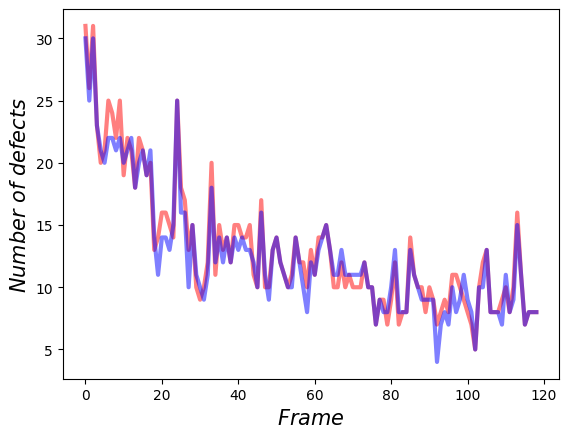

In [64]:
%matplotlib inline
df_plus.groupby('frame').size().plot(linewidth=3, alpha=.5, color="r")
df_minus.groupby('frame').size().plot(linewidth=3, alpha=.5, color="b")

plt.xlabel("$Frame$", fontsize=15)
plt.ylabel("$Number ~of ~defects$", fontsize=15)

# TODO add tracking of defects and detect pairs

In [17]:
# image_list = glob.glob(r"C:\Users\victo\OneDrive - BGU\HBEC\s2(120-1057)\Raw\*.tif")
# image_list = glob.glob(r"C:\Users\victo\Downloads\SB_lab\BEER_DATA\OFdata\40x Phase Contrast (Inside)\*.tif")
# image_list = glob.glob(r"C:\Users\victo\Downloads\SB_lab\BEER_DATA\ISF defects new\6\*.tif")
# image_list = glob.glob(r"C:\Users\victo\OneDrive - BGU\DATA\C2C12 and RPE in 6 well\C2C12_RPE1_15min5x\_1\*\*.tif")
# image_list = glob.glob(r"C:\Users\victo\OneDrive - BGU\DATA\Hacat\6 Wells _5x_15min\_1\Pos0\*.tif")
# image_list = glob.glob(r"C:\Users\victo\OneDrive - BGU\DATA\HT1080\HT1080_5x_5_min_24_well_media_DMSO_C3\_2\Pos41\*.tif")
# image_list = glob.glob(r"E:\Hacat\6 Wells _5x_15min\_3\Pos0\*.tif")
image_list = glob.glob(r"C:\Users\victo\OneDrive - BGU\DATA\Hacat\6Wells_5X_15min_CK666\_1\Pos38\*.tif")
image_list = natsorted(image_list, key=lambda y: y.lower())

first_frame = 0
last_frame = len(image_list)

def uv_list(img1, img2, sigma=15):
    flow = cv2.calcOpticalFlowFarneback(img1,img2, None, 0.5, 3, 
        winsize=sigma, iterations=3, poly_n=5, poly_sigma=1.2, flags=0) 
    flow[..., 0] = flow[..., 0]- np.mean(flow[..., 0])
    flow[..., 1] = flow[..., 1]- np.mean(flow[..., 1])
    return flow[..., 0], flow[..., 1]

vel_list = Parallel(n_jobs=4)(delayed(uv_list)(
    cv2.imread(img1)[:,:,0],
    cv2.imread(img2)[:,:,0],
    sigma=15
    ) for (img1,img2) in zip(image_list[first_frame:last_frame-1],image_list[first_frame+1:last_frame]))

u = [vel[0] for vel in vel_list]
v = [vel[1] for vel in vel_list]

Text(0.5, 1.0, 'Hacat')

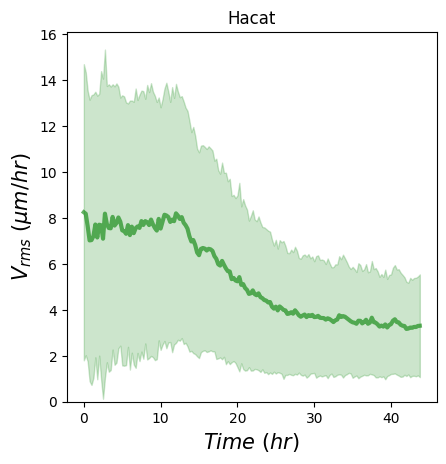

In [18]:
# test time evolution of velocity
%matplotlib inline
fph = 4
px = .9 *2
vrms = np.array([np.mean((uu**2 + vv**2)**.5) for (uu,vv) in zip(u,v)])
std = np.array([np.std((uu**2 + vv**2)**.5) for (uu,vv) in zip(u,v)])

plt.plot(np.arange(len(vrms))/fph, vrms*px*fph, "g", linewidth=3, alpha=.6)
plt.fill_between(np.arange(len(vrms))/fph, (vrms-std)*px*fph, (vrms+std)*px*fph, color="g", alpha=.2)
plt.xlabel("$Time ~(hr)$", fontsize=15)
plt.ylabel("$V_{rms} ~(\mu m/hr)$", fontsize=15)
plt.gca().set_box_aspect(1)
plt.ylim(0, None)
plt.title(str(Path(image_list[0]).parents[3]).split("\\")[-1])

In [19]:
st

NameError: name 'st' is not defined

In [ ]:
for i in range(len(u)):
    print(vel_list[1][0].shape, vel_list[1][1].shape)
# 

In [ ]:
folder = os.path.join(
    str(Path(image_list[0]).parents[0]), 
    'OptFlow_csv')
print(folder)
os.makedirs(folder, exist_ok=True)

C:\Users\victo\OneDrive - BGU\HBEC\s2(120-1057)\OptFlow_csv


In [ ]:
# SAVE u and v as CSV files (for Gil)
for (i, (u_i, v_i)) in enumerate(zip(u, v)):
    ii = first_frame + i
    pd.DataFrame(u_i.astype(np.float16)).to_csv(folder + "/u_"+str(ii)+".csv", index=False)
    pd.DataFrame(v_i.astype(np.float16)).to_csv(folder + "/v_"+str(ii)+".csv", index=False)    

In [ ]:
# test frame
%matplotlib qt
i = 0
step = 15 

fig = plt.figure(figsize=(10,10))

img = cv2.imread(image_list[first_frame+i])[:,:,0]
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
img_clahe = clahe.apply(img)
plt.imshow(255-img_clahe, cmap="gray")

flow = np.stack((vel_list[i][0], vel_list[i][1]), axis=-1)

x = np.arange(0, flow.shape[1], step, dtype=np.int16)
y = np.arange(0, flow.shape[0], step, dtype=np.int16)
plt.quiver(x,y, 
    flow[::step, ::step, 0], -flow[::step, ::step, 1], 
    color="red", scale=100, label="flow", alpha=.5)
plt.title(image_list[first_frame+i])


# image_list

Text(0.5, 1.0, 'C:\\Users\\victo\\OneDrive - BGU\\HBEC\\s2(120-1057)\\Raw\\Trans__200.tif')

In [ ]:
str(Path(image_list[0]).parents[3]).split("\\")[-1]

'HT1080'

In [ ]:
# Save the velocities as npy files
folder = os.path.join(
    str(Path(image_list[0]).parents[0]), 
    'OptFlow')
print(folder)
os.makedirs(folder, exist_ok=True)

for i in range(len(vel_list)):
    # print("Saving velocities for frame {}".format(i))
    
    save_path = folder + r"\{}.npy".format(first_frame+i)
    # os.makedirs(os.path.dirname(folder), exist_ok=True)
    
    np.save(
        save_path,
        np.stack((vel_list[i][0], vel_list[i][1]), axis=-1).astype(np.float16),
    )
    # break

C:\Users\victo\OneDrive - BGU\DATA\HT1080\HT1080_5x_5_min_24_well_media_DMSO_C3\_2\Pos41\OptFlow


Text(0.5, 1.0, 'C:\\Users\\victo\\OneDrive - BGU\\DATA\\C2C12 and RPE in 6 well\\15min5x\\_1\\Pos22\\img_channel000_position022_time000000100_z000.tif')

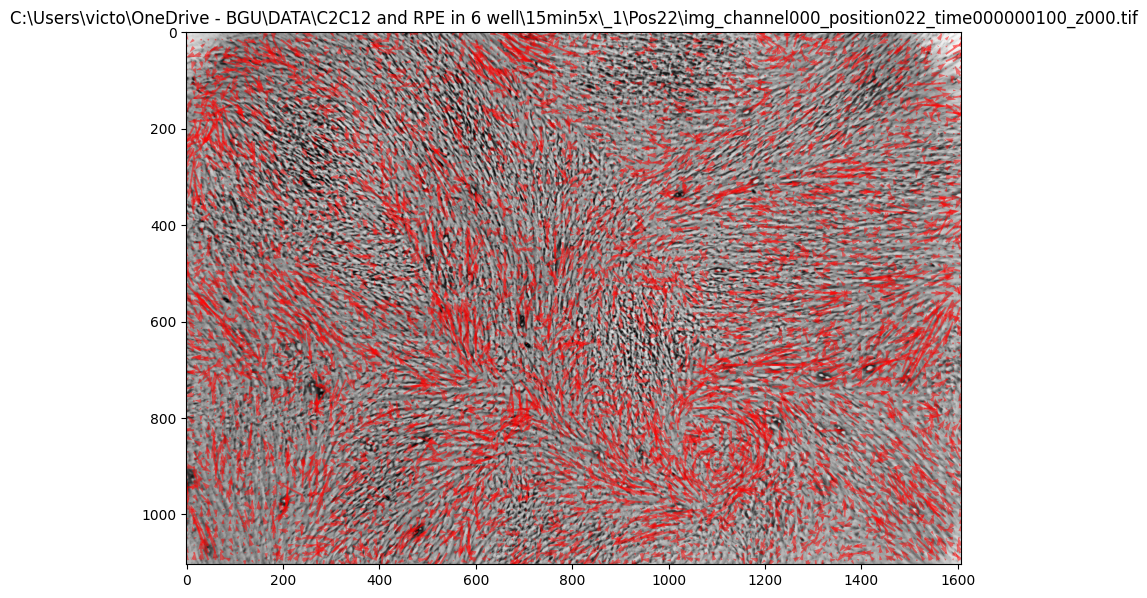

In [ ]:
%matplotlib inline
img_num = 70

i = first_frame+img_num
step = 15 

fig = plt.figure(figsize=(10,10))

save_path = folder + r"\{}.npy".format(i)
flow = np.load(save_path)
img = cv2.imread(image_list[i])[:,:,0]
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
img_clahe = clahe.apply(img)
plt.imshow(255-img_clahe, cmap="gray")
x = np.arange(0, flow.shape[1], step, dtype=np.int16)
y = np.arange(0, flow.shape[0], step, dtype=np.int16)
plt.quiver(x,y, 
    flow[::step, ::step, 0], -flow[::step, ::step, 1], 
    color="red", scale=100, label="flow", alpha=.5)
plt.title(image_list[i])

In [ ]:
image_list = glob.glob(r"C:\Users\victo\OneDrive - BGU\DATA\Hacat\6Wells_5X_15min_CK666\_1\Pos3\*.tif")
# image_list = glob.glob(r"C:\Users\victo\OneDrive - BGU\DATA\Hacat\6 Wells _5x_15min\_1\Pos0\*.tif")
image_list = natsorted(image_list, key=lambda y: y.lower())

first_frame = 120
last_frame = 130 #len(image_list)
box = 150

# NOTICE MINUS analyze_defects(img1, sigma=ori_sigma)[2] is calculated now!

ori_sigma = 11
flow_sigma = 15


u_v_count = Parallel(n_jobs=5)(delayed(defect_flow_frame_average_with_edge)(
    imread(img1), imread(img2), 
    analyze_defects(imread(img1), sigma=ori_sigma)[1][['x','y','ang1']].rename(columns={"x":"xp", "y":"yp", "ang1":"angp1"}),
    defect_type="all", 
    box=(int(box),int(box)),
    filt=1,
    sigma=flow_sigma,
    # vorticity="right",
    ) for img1,img2 in zip(image_list[first_frame:last_frame-1], image_list[first_frame+1:last_frame]))

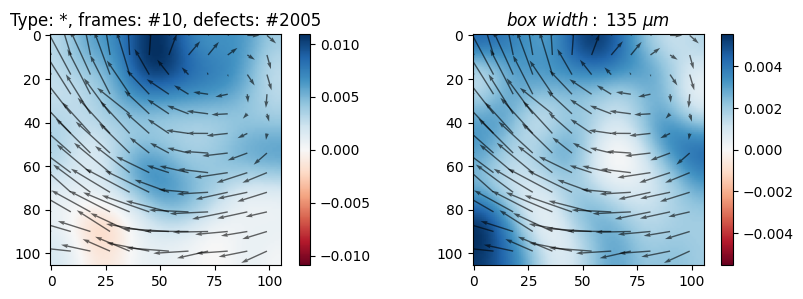

In [17]:
%matplotlib inline
u, v, count = [], [], []
for q in u_v_count:
    if q:
        u.append(q[0])
        v.append(q[1])
        count.append(q[2])
u = np.array(u)
v = np.array(v)
count = np.array(count)  

n, m = 0,-1 #800,900 #600,800 #450,550 #150,250 #50,150
u_up = np.average(u[count!= 0][n:m,:,:], axis=0, weights=count[count!= 0][n:m])
v_up = np.average(v[count!= 0][n:m,:,:], axis=0, weights=count[count!= 0][n:m])

filt = 10
step = 9
vscale = 1

fig, axs = plt.subplots(1,2, figsize=(10,3))
# for ax in axs.ravel(): ax.axis('off')
ax1, ax2 = axs.ravel()

field = np.stack((u_up, v_up), axis=-1)
y, x = np.mgrid[0:u_up.shape[0], 0:u_up.shape[1]] 
vorticity = gaussian_filter(curl_npgrad(field), sigma=filt)
vmin = np.max([np.max(vorticity), -np.min(vorticity)])
c1 = ax1.imshow(vorticity, cmap='RdBu', vmin=-vmin, vmax=vmin)
ax1.quiver(x[::step, ::step], y[::step, ::step], 
          u_up[::step, ::step], -v_up[::step, ::step],  color='k',
          width=.006, scale=vscale, alpha=.6)
ax1.set_title("Type: %1s, frames: #%1d, defects: #%1d" % ("*", last_frame-first_frame, np.sum(count)))
fig.colorbar(c1)

divergence = gaussian_filter(divergence_npgrad(field), sigma=filt)
c2 = ax2.imshow(divergence, cmap='RdBu', vmin=-divergence.max(), vmax=divergence.max())
ax2.quiver(x[::step, ::step], y[::step, ::step], 
          u_up[::step, ::step], -v_up[::step, ::step],  color='k',
          width=.006, scale=vscale, alpha=.6)
ax2.set_title("$box ~width: ~%1d ~\mu m$" % (box * .9))
fig.colorbar(c2)

In [13]:
st

NameError: name 'st' is not defined

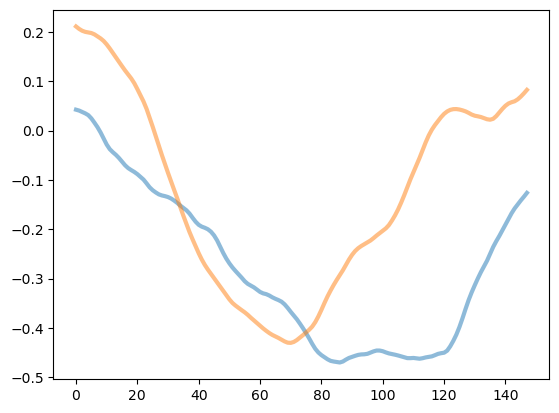

In [ ]:
midlle = u_up.shape[1]//2
plt.plot(u_up[midlle-10:midlle+10,:].mean(axis=0), linewidth=3, alpha=.5)
plt.plot(u_up[:,midlle-10:midlle+10].mean(axis=1), linewidth=3, alpha=.5)

In [ ]:
u_up.max()*1.8*4, u_up.min()

(2.7106034421389427, -0.039223903227850604)

# Mean Flow

In [ ]:
%matplotlib qt
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(6,6))


# ax1.imshow(np.zeros_like(img, dtype=np.float32), cmap="gray")
# "E:\C2C12 and RPE in 6 well\15min5x\_1\Pos18"
image_list = glob.glob(r"E:\HT1080\c3_6well_5min_10x\_2\Pos10\*.tif")
# image_list = glob.glob(r"E:\C2C12 and RPE in 6 well\15min5x\_1\Pos23\*.tif")
image_list = natsorted(image_list, key=lambda y: y.lower())

img = imread(image_list[55])
img_clahe = clahe.apply(img)
ori, plusR, minR =  analyze_defects(img_clahe, sigma=21)

fig, ax1 = plt.subplots()
ax1.axis('off')
ax1.imshow(255-img_clahe, cmap="gray")  

s = 25
y, x = np.mgrid[0:img.shape[0], 0:img.shape[1]]
ax1.quiver(x[::s,::s], y[::s,::s],
    np.cos(ori)[::s,::s], np.sin(ori)[::s,::s], np.arctan2(np.sin(ori), np.cos(ori))[::s,::s],
    headaxislength=0, headwidth=0, headlength=0, width=.005,
    scale=35, pivot='mid', alpha=0.5, cmap='hsv')


alpha_half, scale_half = .8, 20    
ax1.plot(plusR['x'], plusR['y'],'ro',markersize=8, alpha=alpha_half)
ax1.quiver(plusR['x'], plusR['y'], 
    np.cos(plusR['ang1']), -np.sin(plusR['ang1']), 
    headaxislength=0, headwidth=0, headlength=0, color='r', scale=scale_half, alpha=alpha_half)

ax1.plot(minR['x'], minR['y'],'wo',markersize=6, alpha=alpha_half)
for j in range(3):
    ax1.quiver(minR['x'], minR['y'], 
        np.cos(minR['ang'+str(j+1)]), -np.sin(minR['ang'+str(j+1)]), 
        headaxislength=0, headwidth=0, headlength=0, color='w', scale=scale_half, alpha=alpha_half)



plt.gca().set_box_aspect(1)


In [ ]:
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(6,6))

fov_lst = []#[1,2,7,8, 13,14,20,21, 25,26,33,34]
fov_lst = np.arange(1,36)
image_list = glob.glob(r"D:\HT1080\c3_6well_5min_10x\_2\Pos"+str(fov_lst[10])+"\*.tif")
# image_list = glob.glob(r"E:\C2C12 and RPE in 6 well\15min5x\_1\Pos23\*.tif")
image_list = natsorted(image_list, key=lambda y: y.lower())


fig, axs = plt.subplots(1,2, figsize=(10,5))
img_path = image_list[-1]
for ax,img_path in zip(axs, [image_list[4], image_list[-1]]):
    img = imread(img_path)
    img_clahe = clahe.apply(img)

    ax.imshow(255-img_clahe, cmap="gray")  
ax.set_title(os.path.basename(img_path))

Text(0.5, 1.0, 'img_channel000_position011_time000000436_z000.tif')

In [ ]:

image_list = glob.glob(folder+"/Pos*/*.tif")
natsorted(image_list, key=lambda y: y.lower())[-1]

'E:\\HT1080\\c3_6well_5min_10x\\_4\\Pos36\\img_channel000_position036_time000000287_z000.tif'

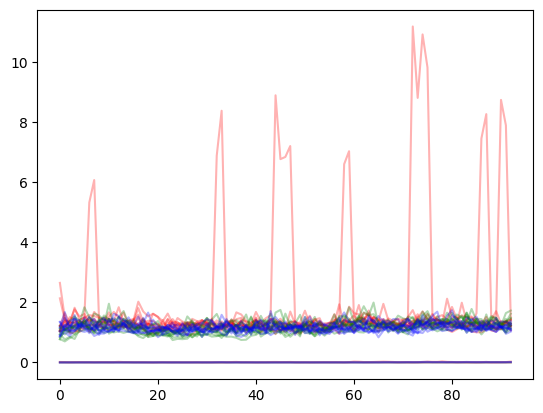

In [ ]:
def u_vel(im1,im2):
    return cv2.calcOpticalFlowFarneback(im1,im2, 
        None, 0.5, 3, winsize=10, iterations=3, poly_n=5, poly_sigma=1.2, flags=0)#.astype(np.float16)

def get_vrms(u,v):
    u = u-u.mean()
    v = v-v.mean()
    return ((u**2 + v**2)**.5).mean()

PLOT = True
# folder = r"E:\HT1080\c3_6well_5min_10x\_2"
folder = r"D:\C2C12 With C3 in 6 well x5 15min\_4"
frame_num = -2
# fov_lst = [6,7,8,10, 13,14,20,21, 25,26,33,34]
fov_lst = np.arange(0,34)
df = pd.DataFrame()

colors = ["r","r","r","r",  "g","g","g","g", "b","b","b","b"]
for i,fov in enumerate(fov_lst):
    image_list = glob.glob(folder+"/Pos"+str(fov)+"\*.tif")
    image_list = natsorted(image_list, key=lambda y: y.lower())

    
    uv_vel_list = Parallel(n_jobs=5)(
        delayed(u_vel)(
            cv2.imread(img1)[...,0],cv2.imread(img2)[...,0]) for (img1,img2) in zip(image_list[:frame_num-1],image_list[1:frame_num]
                        ))
    vrms = [get_vrms(uv[0],uv[1]) for uv in uv_vel_list]
    std = [(uv[0]-uv[0].mean()).std() for uv in uv_vel_list]
    time = np.arange(len(vrms))

    if PLOT:
        if int(fov)<=11: color = "r"
        elif int(fov)>11 and int(fov)<=22: color = "g"
        else: color = "b"        
        plt.plot(time, vrms, color=color, alpha=.3, label="FOV: #%1d|%.3f" % (fov, np.median(vrms)))

    progressBar(i, len(fov_lst))

    df[str(fov)] = vrms
    df[str(fov)+"_std"] = std
    # break
        
# if PLOT: plt.legend()

# df.to_csv(folder+"/_vrms3.csv")

In [ ]:
plt.plot(time, vrms, alpha=.3, label="FOV: #%1d|%.3f" % (fov, np.median(vrms)))

In [ ]:
df.to_csv(folder+"/_vrms3.csv")

Text(0.5, 1.0, 'E:\\HT1080\\c3_6well_5min_10x\\_5')

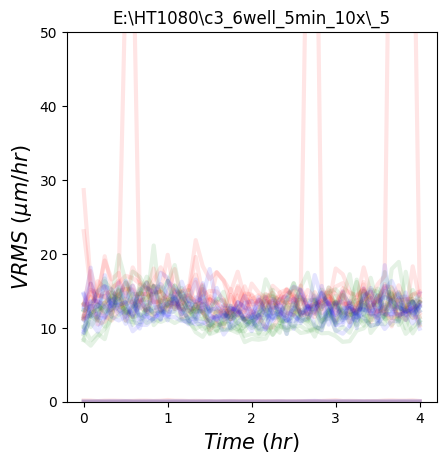

In [ ]:
%matplotlib inline
folder = r"E:\HT1080\c3_6well_5min_10x\_5"
df1 = df#pd.read_csv(folder+"/_vrms3.csv")
exclude_list = [1,2,3,4,5,6,12,18,24,30]
fov_lst = [col for col in df1.keys() if 'std' not in col and col.isdigit() and int(col) not in exclude_list]
fov_lst = np.arange(0,34)

plt.figure()
time = np.arange(len(df1))/12
for i,fov in enumerate(fov_lst[:]):
    if int(fov)<=11: color = "r"
    elif int(fov)>11 and int(fov)<=22: color = "g"
    else: color = "b"

    plt.plot(time, df1[str(fov)] * .9*12, label=str(fov), color=color, alpha=.1, linewidth=3)
    # plt.plot(time, df1[str(fov)] * .9*12, label=str(fov), alpha=.3, linewidth=3)

# plt.legend()
plt.title("VRMS")
plt.xlabel("$Time ~(hr)$", fontsize=15)
plt.ylabel("$VRMS ~(\mu m/hr)$", fontsize=15)
plt.ylim(0, 50)
plt.gca().set_box_aspect(1)
plt.title(folder)

In [ ]:
df = pd.read_csv(r"E:\HT1080\c3_6well_5min_10x\_2\_vrms1.csv")

C:\Users\victo\AppData\Local\Temp\ipykernel_25016\2152427929.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='FOV', y='VRMS', data=df_melted, palette=colors)


(0.0, 60.0)

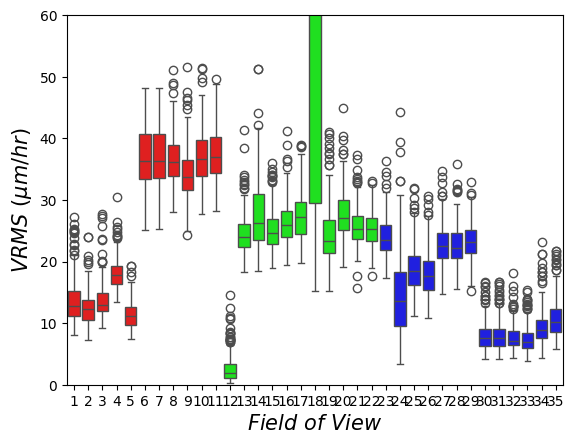

In [ ]:
%matplotlib inline
import seaborn as sns
folder = r"D:\HT1080\c3_6well_5min_10x\_5"
df1 = pd.read_csv(folder+"/_vrms3.csv")
exclude_list = []#[1,2,3,4,5,12,18,24,30]
fov_lst = [col for col in df1.keys() if 'std' not in col and col.isdigit() and int(col) not in exclude_list]

df_selected = df1[[str(fov) for fov in fov_lst]]
df_melted = df_selected.melt(var_name='FOV', value_name='VRMS')

# Set colors based on the condition
colors = [(1,0,0, 0.5) if int(fov) <= 11 else (0,1,0, 0.5) if int(fov) <= 22 else (0,0,1, 0.5) for fov in fov_lst]

df_melted['VRMS'] = df_melted['VRMS'] * .9*12

sns.boxplot(x='FOV', y='VRMS', data=df_melted, palette=colors)
plt.xlabel("$Field ~of ~View$", fontsize=15)
plt.ylabel("$VRMS ~(\mu m/hr)$", fontsize=15)
plt.ylim(0, 60)


In [ ]:
def u_vel(im1,im2):
    return cv2.calcOpticalFlowFarneback(im1,im2, 
        None, 0.5, 3, winsize=15, iterations=3, poly_n=5, poly_sigma=1.2, flags=0)#.astype(np.float16)

frame_num = -2
# uv_vel_list = [u_vel(cv2.imread(img1)[:,900:,0],cv2.imread(img2)[:,900:,0]) for (img1,img2) in zip(image_list[:frame_num-1],image_list[1:frame_num])]
uv_vel_list = Parallel(n_jobs=5)(delayed(u_vel)(cv2.imread(img1)[...,0],cv2.imread(img2)[...,0]) for (img1,img2) in zip(image_list[:frame_num-1],image_list[1:frame_num]))


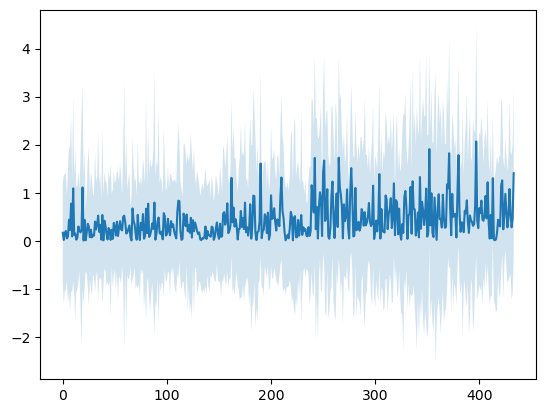

In [ ]:
%matplotlib inline
vrms = [(uv[0].mean()**2 + uv[1].mean()**2)**.5 for uv in uv_vel_list]
std = [uv[0].std() for uv in uv_vel_list]
time = np.arange(len(vrms))
plt.plot(time, vrms)
plt.fill_between(time, np.array(vrms)-np.array(std), np.array(vrms)+np.array(std), alpha=.2)

In [ ]:
%matplotlib qt
n = 9
img1 = cv2.imread(image_list[n])[:,:,0]
img2 = cv2.imread(image_list[n+1])[:,:,0]
flow = cv2.calcOpticalFlowFarneback(img1,img2, None, 0.5, 3, 
    winsize=10, iterations=3, poly_n=5, poly_sigma=1.2, flags=0) 
flow[..., 0] = gaussian_filter(flow[..., 0], sigma=5)
flow[..., 1] = gaussian_filter(flow[..., 1], sigma=5)

step = 10
fig, ax1 = plt.subplots(1,1)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(6,6))
img_clahe = clahe.apply(img1)
ax1.imshow(255-img_clahe, cmap="gray")

x = np.arange(0, flow.shape[1], step, dtype=np.int16)
y = np.arange(0, flow.shape[0], step, dtype=np.int16)
ax1.quiver(x,y, 
        flow[::step, ::step, 0], -flow[::step, ::step, 1], #np.arctan2(flow[:,:, 1], flow[:,:,  0])[::step,::step],
        color="red", scale=50, alpha=.6, cmap='hsv', width=.003)

fig, ax2 = plt.subplots(1,1,  figsize=(4,4))
# ax2.hist(np.concatenate(v)/(i+1), 60, alpha=.3, rwidth=.9, density=True, label="v")
# ax2.hist(np.concatenate(u)/(i+1),60, alpha=.8, rwidth=.8, density=True, label="u")
ax2.hist(flow[..., 1].ravel(), 60, alpha=.3, rwidth=.9, density=True, label="v")
ax2.hist(flow[..., 0].ravel(),60, alpha=.8, rwidth=.8, density=True, label="u")
plt.legend(loc='upper right', fontsize=14)

vrms = (flow[..., 0].mean()**2 + flow[..., 1].mean()**2)**.5
print(vrms.mean())

0.91050833
